<a href="https://colab.research.google.com/github/MarioDLCruz/PolisemiaV1/blob/main/umap1k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import umap

In [3]:
import pandas as pd

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
import numpy as np

In [6]:
umap.UMAP

umap.umap_.UMAP

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
file_path = '/content/drive/MyDrive/tokens1k.csv'
df = pd.read_csv(file_path)

In [ ]:
df

,token,id_tweet,region,id_vector,vector
0,[CLS],0,Jalisco,0,"[0.0132701714, -0.017905375, -0.00618814072, -..."
1,Jalisco,0,Jalisco,1,"[0.00420953473, -0.0329080522, 0.0130279278, -..."
2,_GEO,0,Jalisco,2,"[-0.0135559319, -0.00135187013, 0.0171045307, ..."
3,_USR,0,Jalisco,3,"[-0.0358271115, -0.0446212329, 0.0243038628, -..."
4,Se,0,Jalisco,4,"[0.0286497883, -0.0264977496, 0.0178820007, -0..."
...,...,...,...,...,...
30348,##I,999,Mexico_City,19,"[0.00951175019, 0.00765987625, 0.0700742528, -..."
30349,##f,999,Mexico_City,20,"[-0.00696010841, -0.0221082475, 0.00697800005,..."
30350,😭,999,Mexico_City,21,"[-0.0522314981, -0.0729229525, -0.0257079042, ..."
30351,_URL,999,Mexico_City,22,"[-0.0176484715, -0.091482833, -0.000317632803,..."


In [9]:
reducer = umap.UMAP()

In [10]:
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


In [11]:
import numpy as np
import re

def parse_vector(v_str):
    # Elimina los corchetes si existen y divide por espacios
    clean_str = re.sub(r'[\[\]]', '', v_str)
    # Convierte en lista de floats
    return np.fromstring(clean_str, sep=' ')

# Aplica la conversión
df['vector'] = df['vector'].apply(parse_vector)


In [23]:
from sklearn.preprocessing import StandardScaler
import umap

X = np.vstack(df['vector'].values)
X/=np.linalg.norm(X, axis=1).reshape(-1, 1)
X.shape
embedding = umap.UMAP(metric="cosine").fit_transform(X)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [21]:
np.linalg.norm(X[0])

np.float64(1.0)

In [13]:
X.shape

(30353,)

In [ ]:
embedding.shape

(30353, 2)

In [27]:
import matplotlib.pyplot as plt

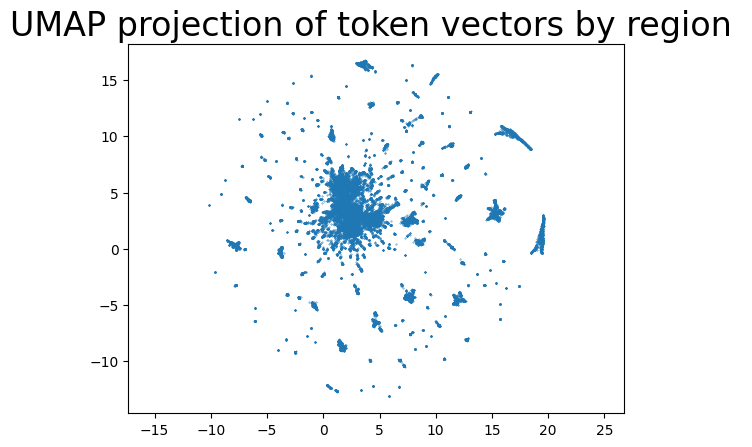

In [40]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=.1,
    )

    #c=[palette[i] for i in region_indices])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of token vectors by region ', fontsize=24);

In [56]:
df["x"] = embedding[:, 0]
df["y"] = embedding[:, 1]
df[["token", "region", "x", "y"]]


,token,region,x,y
0,[CLS],Jalisco,19.462255,2.092136
1,Jalisco,Jalisco,8.639838,11.838120
2,_GEO,Jalisco,15.490259,3.203871
3,_USR,Jalisco,-3.797880,-0.077880
4,Se,Jalisco,2.792879,-3.314565
...,...,...,...,...
30348,##I,Mexico_City,0.422009,4.403575
30349,##f,Mexico_City,0.837913,5.001264
30350,😭,Mexico_City,7.216051,2.079504
30351,_URL,Mexico_City,8.435128,0.702224


In [72]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="region",
    hover_data=["token", "region", "id_tweet"],
    title="UMAP projection of token vectors by region",
    width=1000,
    height=700
)


fig.update_traces(marker=dict(size=3, opacity=0.6), selector=dict(mode='markers'))
fig.update_layout(legend_title="Región", title_x=0.5)

fig.show()
